In [5]:
# Library yg akan dipakai

import os
import ast
import pandas as pd
import stat
import re
import time
import subprocess

import json
import nbformat

import networkx as nx


In [6]:
akun_file = r"D:\PUTRI\D4\SEMESTER 7 (TeFa)\skripsi\code\asli\akungit3G.txt"
projects_folder = r"D:\PUTRI\D4\SEMESTER 7 (TeFa)\skripsi\code\source_code"
os.makedirs(projects_folder, exist_ok=True)

In [7]:
# Fungsi untuk membaca file txt yang berisi daftar link repo github Mahasiswa

def load_repo_list(file_path):
    repo_list = []

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} tidak ditemukan")

    with open(file_path, "r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()

            if not line:
                continue

            parts = line.split("|")
            if len(parts) != 3:
                print(f"[WARNING] Format salah di baris {line_number}: {line}")
                continue

            nama, nim, repo_url = parts

            repo_list.append({
                "nama": nama.strip(),
                "nim": nim.strip(),
                "repo_url": repo_url.strip()
            })

    return repo_list

In [8]:
# Fungsi untuk mengambil file .py dan .ipynb saja

def keep_only_python_files(repo_path):
    # 1. Hapus file non .py dan .ipynb
    for root, dirs, files in os.walk(repo_path):
        if ".git" in dirs:
            dirs.remove(".git")

        for file in files:
            if not (file.endswith(".py") or file.endswith(".ipynb")):
                try:
                    os.remove(os.path.join(root, file))
                except PermissionError:
                    pass  # abaikan file yang tidak bisa dihapus

    # 2. Hapus folder kosong
    for root, dirs, files in os.walk(repo_path, topdown=False):
        if ".git" in dirs:
            dirs.remove(".git")

        if not os.listdir(root):
            try:
                os.rmdir(root)
            except OSError:
                pass

In [9]:
# Fungsi untuk mulai clone repo mahasiswa dan menyisakan file .py dan .ipynb

def clone_and_filter_repo(nama, nim, repo_url, target_dir, delay=2):
    # Nama folder menggunakan Nama mahasiswa
    safe_name = re.sub(r'[<>:"/\\|?* ]+', '_', nama)
    folder_name = f"{safe_name}"
    target_path = os.path.join(target_dir, folder_name)

    if os.path.exists(target_path):
        print(f"[SKIP] {folder_name} sudah ada.")
        return

    print(f"[CLONE] {folder_name}")

    try:
        subprocess.run(
            ["git", "clone", repo_url, target_path],
            check=True,
            timeout=300,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE
        )

        # Seleksi file kode untuk menghapus file selain .py/.ipynb
        keep_only_python_files(target_path)

        time.sleep(delay)

    except subprocess.TimeoutExpired:
        print(f"   ⏰ Timeout saat clone {repo_url}")

    except subprocess.CalledProcessError as e:
        print(f"   ❌ Gagal clone {repo_url} (Cek izin repo/token)")
        print(e.stderr.decode())


In [10]:
repo_mahasiswa = load_repo_list(akun_file)

print(f"Total repo mahasiswa: {len(repo_mahasiswa)}\n")

for data in repo_mahasiswa:
    clone_and_filter_repo(
        nama=data["nama"],
        nim=data["nim"],
        repo_url=data["repo_url"],
        target_dir=projects_folder,
        delay=2
    )

print("\n--- Proses cloning selesai ---")

Total repo mahasiswa: 10

[SKIP] ADITYA_ATADEWA sudah ada.
[SKIP] AFIFAH_KHOIRUNNISA sudah ada.
[SKIP] AFRIZAL_QURRATUL_FAIZIN sudah ada.
[SKIP] AHMAD_NAUFAL_ILHAM sudah ada.
[SKIP] ANYA_CALLISSTA_CHRISWANTARI sudah ada.
[SKIP] ARIL_IBBET_ARDANA_PUTRA sudah ada.
[SKIP] ARYO_ADI_PUTRO sudah ada.
[SKIP] CAKRA_WANGSA_MAY_AHMAD_WIDODO sudah ada.
[SKIP] CHIKO_ABILLA_BASYA sudah ada.
[SKIP] DAMAR_GALIH_FITRIANTO sudah ada.

--- Proses cloning selesai ---


In [11]:

def classify_and_extract_practicum(filename):
    name = filename.lower()

    # Case tugas kelompok
    if "kelompok" in name:
        match_kel = re.search(r"kelompok[_ ]?(\d+)", name)
        if match_kel:
            return "KELOMPOK", int(match_kel.group(1))
        return "KELOMPOK", None
    
    # Case dalam folder Kuis
    if "kuis" in name:
        return "KUIS", None

    # Case Tugas Praktikum (TP)
    if "tp" in name or "tugas" in name or "project" in name:
        return "TP", None

    # Case Praktikum P1, P2, P10, dst
    match_p = re.search(r"\bp(\d+)", name)
    if match_p:
        pract_num = int(match_p.group(1))
        return "PRAKTIKUM", pract_num

    # Case Tidak terdeteksi → fallback
    return "PRAKTIKUM", None


In [12]:
#Normalisasi nama foldernya, untuk folder JS, Kuis, PBL_Kelompok

def normalize_module_folder_name(folder_name):
    """
    Aturan:
    - JSxx            → Mxx
    - KUIS            → kuis
    - PBL_Kelompokx   → PBLxx
    - Kelompok        → kelompok
    """

    name = folder_name.upper()

    # JS01 → M01
    match_js = re.match(r"JS(\d+)", name)
    if match_js:
        number = int(match_js.group(1))
        return f"M{number:02d}"

    # KUIS → kuis
    if name == "KUIS":
        return "kuis"

    # PBL_Kelompok2 → PBL02
    match_pbl = re.match(r"PBL[_ ]?KELOMPOK(\d+)", name)
    if match_pbl:
        number = int(match_pbl.group(1))
        return f"PBL{number:02d}"

    # KELOMPOK → kelompok
    if name == "KELOMPOK":
        return "kelompok"

    return None

In [13]:
def normalize_task_files(module_path):
    task_files = [
        f for f in os.listdir(module_path)
        if f.endswith(".py") or f.endswith(".ipynb")
    ]

    # Counter untuk kasus ganda
    fallback_praktikum = 1
    tp_counter = 1
    kuis_counter = 1
    kelompok_counter = 1

    for file in task_files:
        old_path = os.path.join(module_path, file)
        task_type, number = classify_and_extract_practicum(file)
        ext = os.path.splitext(file)[1]

        # ===== CASE: KELOMPOK =====
        if task_type == "KELOMPOK":
            if number is not None:
                new_name = f"Kelompok{number:02d}{ext}"
            else:
                new_name = f"Kelompok{kelompok_counter:02d}{ext}"
                kelompok_counter += 1

        # ===== CASE: KUIS =====
        elif task_type == "KUIS":
            if kuis_counter == 1:
                new_name = f"Kuis{ext}"
            else:
                new_name = f"Kuis{kuis_counter:02d}{ext}"
            kuis_counter += 1

        # ===== CASE: TP =====
        elif task_type == "TP":
            if tp_counter == 1:
                new_name = f"TP{ext}"
            else:
                new_name = f"TP{tp_counter:02d}{ext}"
            tp_counter += 1

        # ===== CASE: PRAKTIKUM =====
        else:  # PRAKTIKUM
            if number is not None:
                new_name = f"P{number:02d}{ext}"
            else:
                new_name = f"P{fallback_praktikum:02d}{ext}"
                fallback_praktikum += 1

        new_path = os.path.join(module_path, new_name)

        # Hindari overwrite file
        if old_path != new_path and not os.path.exists(new_path):
            os.rename(old_path, new_path)


In [14]:
def normalize_student_directory(student_path):
    student_name = os.path.basename(student_path)

    print(f"\n Mulai normalisasi mahasiswa: {student_name}")

    for item in os.listdir(student_path):
        old_path = os.path.join(student_path, item)

        if not os.path.isdir(old_path):
            continue

        new_name = normalize_module_folder_name(item)
        if new_name is None:
            continue

        new_path = os.path.join(student_path, new_name)

        if old_path != new_path:
            print(f"   🔄 Folder: {item} → {new_name}")
            os.rename(old_path, new_path)
        else:
            print(f"   ✔ Folder: {item} (tidak berubah)")

        print(f"      📄 Normalisasi file di folder {new_name}")
        normalize_task_files(new_path)

    print(f"✅ Selesai normalisasi mahasiswa: {student_name}")


In [15]:
# looping untuk melakukan normalisasi

for student_folder in os.listdir(projects_folder):
    student_path = os.path.join(projects_folder, student_folder)

    if os.path.isdir(student_path):
        normalize_student_directory(student_path)

print("\n--- Normalisasi struktur direktori & nama file selesai ---")


 Mulai normalisasi mahasiswa: ADITYA_ATADEWA
   🔄 Folder: KELOMPOK → kelompok
      📄 Normalisasi file di folder kelompok
   ✔ Folder: kuis (tidak berubah)
      📄 Normalisasi file di folder kuis
✅ Selesai normalisasi mahasiswa: ADITYA_ATADEWA

 Mulai normalisasi mahasiswa: AFIFAH_KHOIRUNNISA
✅ Selesai normalisasi mahasiswa: AFIFAH_KHOIRUNNISA

 Mulai normalisasi mahasiswa: AFRIZAL_QURRATUL_FAIZIN
✅ Selesai normalisasi mahasiswa: AFRIZAL_QURRATUL_FAIZIN

 Mulai normalisasi mahasiswa: AHMAD_NAUFAL_ILHAM
   🔄 Folder: KELOMPOK → kelompok
      📄 Normalisasi file di folder kelompok
   ✔ Folder: kuis (tidak berubah)
      📄 Normalisasi file di folder kuis
✅ Selesai normalisasi mahasiswa: AHMAD_NAUFAL_ILHAM

 Mulai normalisasi mahasiswa: ANYA_CALLISSTA_CHRISWANTARI
   🔄 Folder: KELOMPOK → kelompok
      📄 Normalisasi file di folder kelompok
   ✔ Folder: kuis (tidak berubah)
      📄 Normalisasi file di folder kuis
✅ Selesai normalisasi mahasiswa: ANYA_CALLISSTA_CHRISWANTARI

 Mulai normalisa

In [16]:
# validasi untuk syntax pythonnya

def validate_python_syntax(code):
    try:
        ast.parse(code)
        return True
    except SyntaxError:
        return False

In [17]:
# mengekstrak kode python dari filenya

def read_py_file(file_path): # untuk file .py
    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        return f.read()

def read_ipynb_file(file_path): # untuk file .ipynb
    nb = nbformat.read(file_path, as_version=4)
    code_cells = []

    for cell in nb.cells:
        if cell.cell_type == "code":
            code_cells.append(cell.source)

    return "\n".join(code_cells)


In [18]:
# Fungsi untuk menghapus baris kosong dan komentar

def remove_comments_and_blank_lines(code):
    cleaned_lines = []

    for line in code.splitlines():
        stripped = line.strip()

        # Skip baris kosong
        if not stripped:
            continue

        # Skip komentar
        if stripped.startswith("#"):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


In [19]:
# menormalisasi struktur kode untuk Menghilangkan perbedaan spasi, indent, gaya penulisan

def normalize_code_format(code):
    try:
        tree = ast.parse(code)
        normalized_code = ast.unparse(tree)
        return normalized_code
    except Exception:
        return code

In [20]:
# Melakukan preprocessing tiap filenya

def preprocess_code(file_path):
    if file_path.endswith(".py"):
        original_code = read_py_file(file_path)
    elif file_path.endswith(".ipynb"):
        original_code = read_ipynb_file(file_path)
    else:
        return None

    is_valid = validate_python_syntax(original_code)

    if not is_valid:
        return {
            "original_code": original_code,
            "clean_code": None,
            "status": "syntax_error"
        }

    cleaned = remove_comments_and_blank_lines(original_code)
    normalized = normalize_code_format(cleaned)

    return {
        "original_code": original_code,
        "clean_code": normalized,
        "status": "valid"
    }

In [21]:
# Looping untuk preprocessing 1 dataset

def preprocess_dataset(base_dir):
    results = {}

    for student in os.listdir(base_dir):
        student_path = os.path.join(base_dir, student)

        if not os.path.isdir(student_path):
            continue

        results[student] = {}

        for root, dirs, files in os.walk(student_path):
            for file in files:
                if file.endswith(".py") or file.endswith(".ipynb"):
                    file_path = os.path.join(root, file)
                    rel_path = os.path.relpath(file_path, student_path)

                    result = preprocess_code(file_path)
                    if result:
                        results[student][rel_path] = result

    return results


In [22]:
# Mulai preprocessing

results = preprocess_dataset(projects_folder)

print("\n--- Prepocessing selesai ---")
print(f"Total mahasiswa diproses: {len(results)}")

d:\PUTRI\D4\SEMESTER 7 (TeFa)\skripsi\code\venv_karate\lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)



--- Prepocessing selesai ---
Total mahasiswa diproses: 10


In [23]:
# Memparsing dari code yang sudah bersih ke AST

def parse_code_to_ast(code):
    try:
        return ast.parse(code)
    except SyntaxError:
        return None

In [24]:
# Mengubah AST menjadi bentuk graph

def ast_to_graph(ast_tree):
    graph = nx.Graph()
    node_counter = 0

    def visit(node, parent_id=None):
        nonlocal node_counter

        current_id = node_counter
        graph.add_node(current_id, label=type(node).__name__)
        node_counter += 1

        if parent_id is not None:
            graph.add_edge(parent_id, current_id)

        for child in ast.iter_child_nodes(node):
            visit(child, current_id)

    visit(ast_tree)
    return graph


In [25]:
# Menghimpun seluruh graf AST dari hasil preprocessing

def build_graph_collection(results):
    graph_collection = []
    graph_metadata = []

    for student, files in results.items():
        for rel_path, data in files.items():

            if data["status"] != "valid":
                continue

            code = data["clean_code"]
            ast_tree = parse_code_to_ast(code)

            if ast_tree is None:
                continue

            graph = ast_to_graph(ast_tree)
            graph_collection.append(graph)

            graph_metadata.append({
                "student": student,
                "file": rel_path
            })

    return graph_collection, graph_metadata


In [26]:
graph_collection, graph_metadata = build_graph_collection(results)

print(f"Total graf berhasil dibuat: {len(graph_collection)}")

Total graf berhasil dibuat: 354


In [27]:
from karateclub import Graph2Vec
import numpy as np

In [28]:
# Inisialisasi Model Graph2Vec

graph2vec_model = Graph2Vec(
    dimensions=128,        # dimensi embedding /panjang vektor embedding
    wl_iterations=2,       # Weisfeiler-Lehman iterations, kedalaman eksplorasi struktur graf
    epochs=50,             # jumlah training epoch
    learning_rate=0.025,   # learning rate
    min_count=1,
    seed=42
)

In [29]:
graph2vec_model.fit(graph_collection)

In [30]:
embeddings = graph2vec_model.get_embedding()
print(embeddings.shape)

(354, 128)


In [31]:
task_embeddings = []

total_graph = len(embeddings)
print(f"   Total graf / tugas: {total_graph}")

for idx, vector in enumerate(embeddings):
    task_embeddings.append({
        "student": graph_metadata[idx]["student"],
        "file": graph_metadata[idx]["file"],
        "embedding": vector
    })

    # Tampilkan contoh 3 data pertama sebagai preview
    if idx < 2:
        print(f"\n📌 Preview data ke-{idx+1}:")
        print(f"   Mahasiswa : {graph_metadata[idx]['student']}")
        print(f"   File      : {graph_metadata[idx]['file']}")
        print(f"   Embedding : {vector[:8]} ...")  # cuplikan 8 nilai awal

print(f"   Total embedding tersimpan: {len(task_embeddings)}")

   Total graf / tugas: 354

📌 Preview data ke-1:
   Mahasiswa : ADITYA_ATADEWA
   File      : kelompok\Kelompok05.ipynb
   Embedding : [ 0.78221893  0.34269702  0.62662894 -0.6171827  -0.2007522  -0.20005637
 -0.09385113  0.8419731 ] ...

📌 Preview data ke-2:
   Mahasiswa : ADITYA_ATADEWA
   File      : M01\TP02.ipynb
   Embedding : [-0.05500966  0.66051173 -0.37492606 -0.39569068  0.5206856   0.04567648
  0.07629345  0.17659944] ...
   Total embedding tersimpan: 354


In [32]:
from sklearn.metrics.pairwise import cosine_similarity

In [33]:
# mengambil info modul berapa, file apa
    # Mengambil modul dan jenis tugas dari path file.
    # Sementara Dibatasi hanya untuk file di folder Mxx.
    
    # Return:
    # - (module, task) jika valid
    # - (None, None) jika tidak memenuhi format

def parse_module_and_task(file_path):

    parts = file_path.replace("\\", "/").split("/")

    # Harus minimal: Mxx/filename.py
    if len(parts) < 2:
        return None, None

    module = parts[0]

    # Hanya modul Mxx yang diproses
    if not module.startswith("M"):
        return None, None

    task = os.path.splitext(parts[-1])[0]
    return module, task

In [34]:
from collections import defaultdict

grouped_tasks = defaultdict(list)

for item in task_embeddings:
    module, task = parse_module_and_task(item["file"])

    # Skip jika bukan modul Mxx
    if module is None or task is None:
        continue

    grouped_tasks[(module, task)].append(item)

In [35]:
# Menghitung nilai kemiripan

similarity_results = []

for (module, task), items in grouped_tasks.items():
    if len(items) < 2:
        continue  # tidak bisa dibandingkan

    embeddings = np.array([x["embedding"] for x in items])
    students = [x["student"] for x in items]

    sim_matrix = cosine_similarity(embeddings)

    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            similarity_results.append({
                "module": module,
                "task": task,
                "student_1": students[i],
                "student_2": students[j],
                "similarity": float(sim_matrix[i, j])
            })

In [36]:
# Mendeteksi klon dengan threshold tertentu
SIMILARITY_THRESHOLD = 0.85

clone_candidates = [
    r for r in similarity_results
    if r["similarity"] >= SIMILARITY_THRESHOLD
]

for r in clone_candidates:
    r["similarity_percent"] = round(r["similarity"] * 100, 2)

In [37]:
clone_candidates[:3]

[{'module': 'M02',
  'task': 'P01',
  'student_1': 'ADITYA_ATADEWA',
  'student_2': 'ANYA_CALLISSTA_CHRISWANTARI',
  'similarity': 0.8810609579086304,
  'similarity_percent': 88.11},
 {'module': 'M02',
  'task': 'P01',
  'student_1': 'ADITYA_ATADEWA',
  'student_2': 'DAMAR_GALIH_FITRIANTO',
  'similarity': 0.9924852252006531,
  'similarity_percent': 99.25},
 {'module': 'M02',
  'task': 'P01',
  'student_1': 'ANYA_CALLISSTA_CHRISWANTARI',
  'student_2': 'DAMAR_GALIH_FITRIANTO',
  'similarity': 0.8828437924385071,
  'similarity_percent': 88.28}]

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_single_similarity_heatmap(grouped_tasks, module, task, threshold=None):
    key = (module, task)
    items = grouped_tasks.get(key, [])

    if len(items) < 2:
        print(f"Tidak cukup data untuk {module} {task}")
        return

    labels = [x["student"] for x in items]
    embeddings = np.array([x["embedding"] for x in items])

    sim_matrix = cosine_similarity(embeddings)
    df_sim = pd.DataFrame(sim_matrix, index=labels, columns=labels)

    plt.figure(figsize=(14, 12))
    sns.heatmap(
        df_sim,
        cmap="Blues",
        vmin=0,
        vmax=1,
        annot=False
    )

    title = f"Heatmap Kemiripan Kode – {module} {task}"
    if threshold is not None:
        title += f" (Threshold = {threshold})"

    plt.title(title)
    plt.tight_layout()
    plt.show()

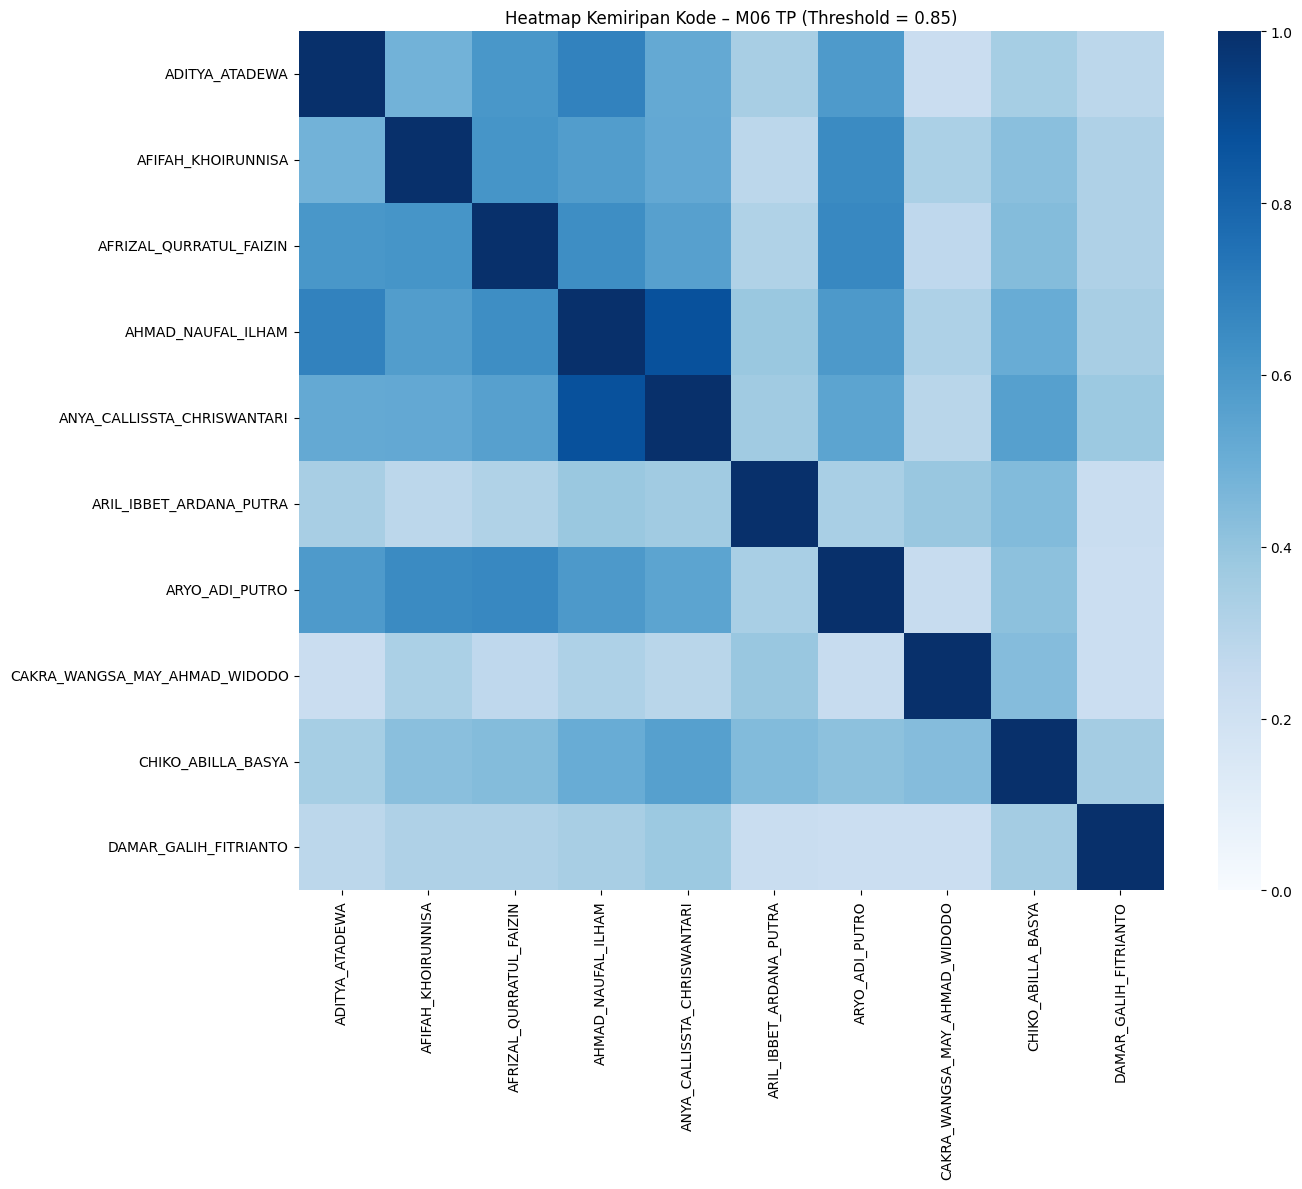

In [77]:
plot_single_similarity_heatmap(
    grouped_tasks,
    module="M06",
    task="TP",
    threshold=SIMILARITY_THRESHOLD
)

In [68]:
import pandas as pd

df_similarity = pd.DataFrame(similarity_results)

print(f"Total pasangan dibandingkan: {len(df_similarity)}")
# Tambahkan kolom persen
df_similarity["similarity_percent"] = (
    df_similarity["similarity"] * 100
).round(2)

df_similarity.head(380)

Total pasangan dibandingkan: 1214


,module,task,student_1,student_2,similarity,similarity_percent
0,M02,P01,ADITYA_ATADEWA,ANYA_CALLISSTA_CHRISWANTARI,0.881061,88.11
1,M02,P01,ADITYA_ATADEWA,DAMAR_GALIH_FITRIANTO,0.992485,99.25
2,M02,P01,ANYA_CALLISSTA_CHRISWANTARI,DAMAR_GALIH_FITRIANTO,0.882844,88.28
3,M02,P02,ADITYA_ATADEWA,AFIFAH_KHOIRUNNISA,0.814546,81.45
4,M02,P02,ADITYA_ATADEWA,AFRIZAL_QURRATUL_FAIZIN,0.665179,66.52
...,...,...,...,...,...,...
375,M05,TP,ANYA_CALLISSTA_CHRISWANTARI,CAKRA_WANGSA_MAY_AHMAD_WIDODO,0.378502,37.85
376,M05,TP,ANYA_CALLISSTA_CHRISWANTARI,CHIKO_ABILLA_BASYA,0.603082,60.31
377,M05,TP,ANYA_CALLISSTA_CHRISWANTARI,DAMAR_GALIH_FITRIANTO,0.373518,37.35
378,M05,TP,ARIL_IBBET_ARDANA_PUTRA,CAKRA_WANGSA_MAY_AHMAD_WIDODO,0.380919,38.09


In [69]:
output_path = "similarity_score_Graph2vec.xlsx"
df_similarity.to_excel(output_path, index=False)

print(f"File disimpan: {output_path}")

File disimpan: similarity_score_Graph2vec.xlsx
